## Carregar pacotes

In [1]:
import pandas as pd
from sklearn.model_selection import ShuffleSplit
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## Carregar conjunto de dados Iris

In [4]:
dataset_iris = pd.read_csv('../iris/data/Iris.csv')
dataset_iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


## Remover a coluna `Id`

In [5]:
dataset_iris.drop(columns=['Id'], inplace=True)
dataset_iris

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


## Transformando os rótulos em valores contínuos 

In [6]:
dataset_iris['Species'] = pd.factorize(dataset_iris['Species'])[0]
dataset_iris

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


## Gráfico da disposição dos exemplos do conjunto Iris em dois eixos

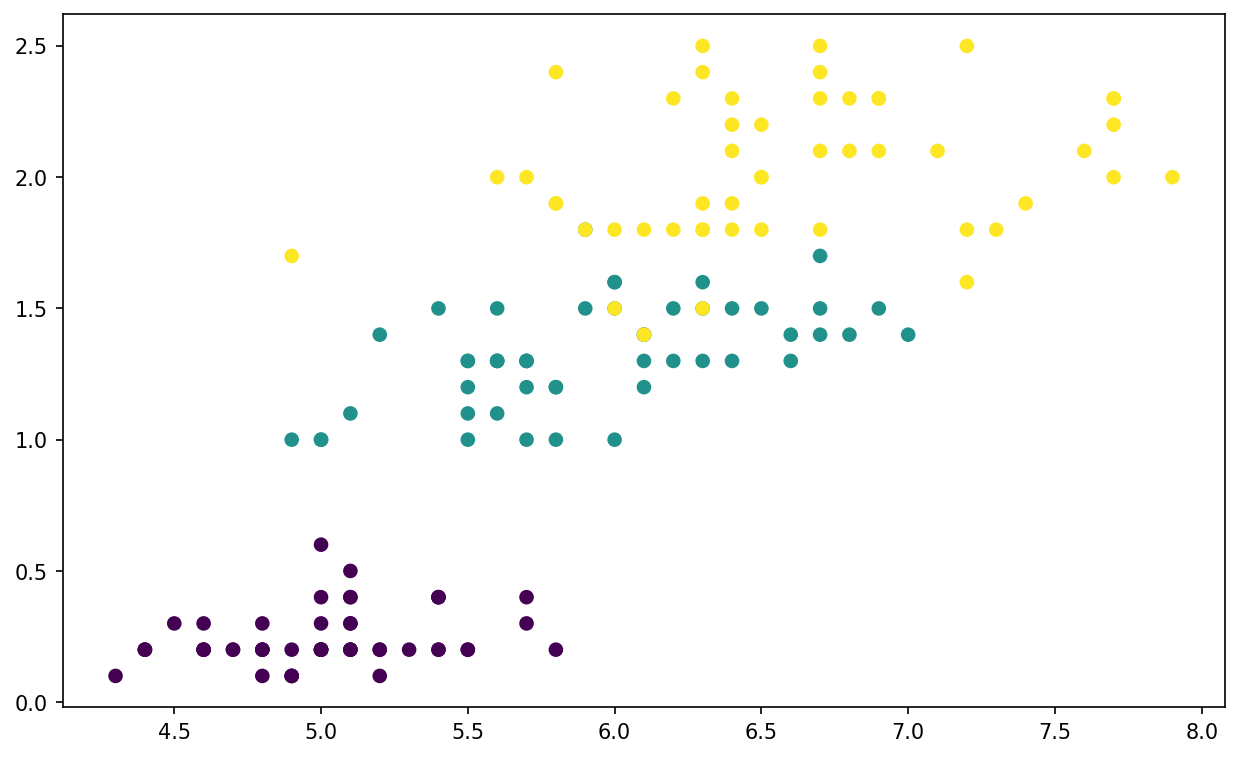

In [7]:
fig, ax = plt.subplots()
ax.scatter(dataset_iris['SepalLengthCm'], dataset_iris['PetalWidthCm'], c=dataset_iris['Species'])


plt.show()

# Dividir o conjunto de dados em treino e teste
## 80% treino e 20% teste

In [8]:
splitter = ShuffleSplit(n_splits=1, test_size=.20)
strat_splits = []
for train_index, test_index in splitter.split(dataset_iris):
    train_set_n = dataset_iris.iloc[train_index]
    test_set_n = dataset_iris.iloc[test_index]
    strat_splits.append([train_set_n, test_set_n])


train_set = strat_splits[0][0]
test_set = strat_splits[0][1]

print('Total de exemplos')
print(f'Treino: {len(train_set)}')
print(f'Teste: {len(test_set)}')

Total de exemplos
Treino: 120
Teste: 30


## Gráfico da disposição dos exemplos dos conjuntos de treino

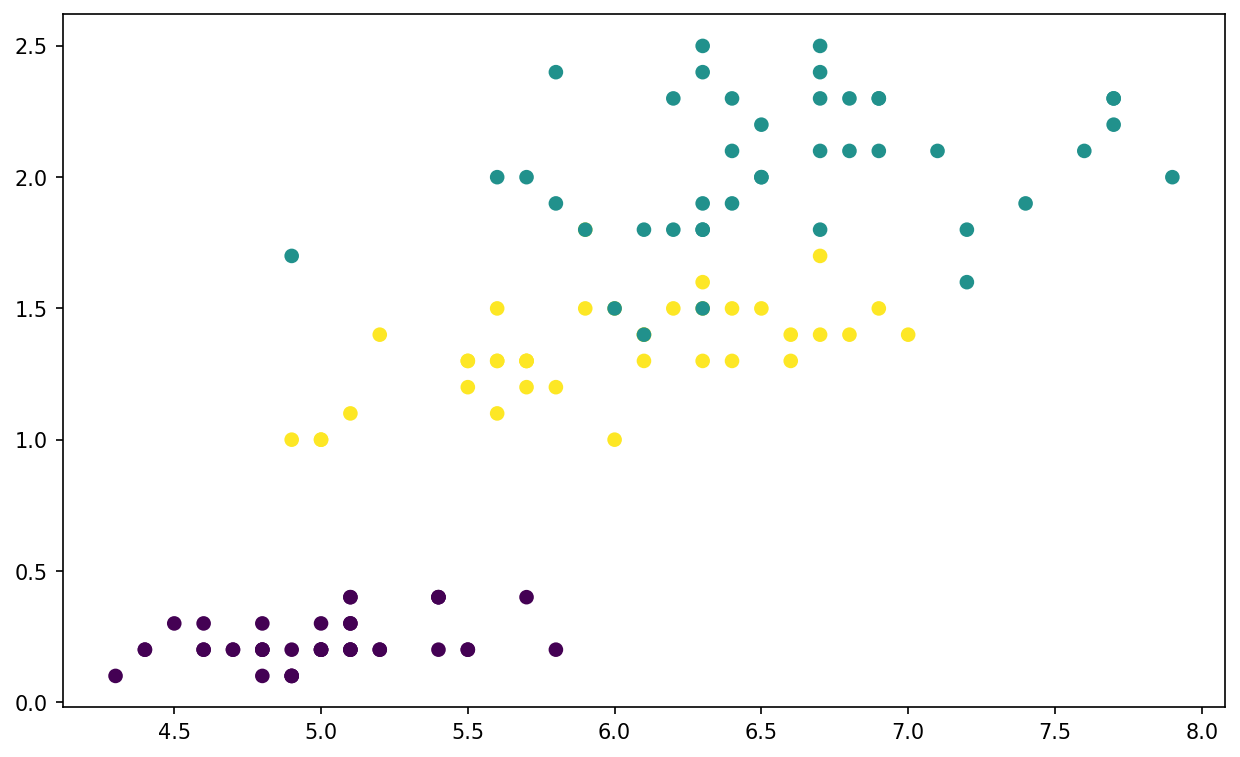

In [9]:
dataset = train_set

fig, ax = plt.subplots()
ax.scatter(dataset['SepalLengthCm'], dataset['PetalWidthCm'], c=[pd.factorize(dataset['Species'])[0]])


plt.show()

## Gráfico da disposição dos exemplos dos conjuntos de teste

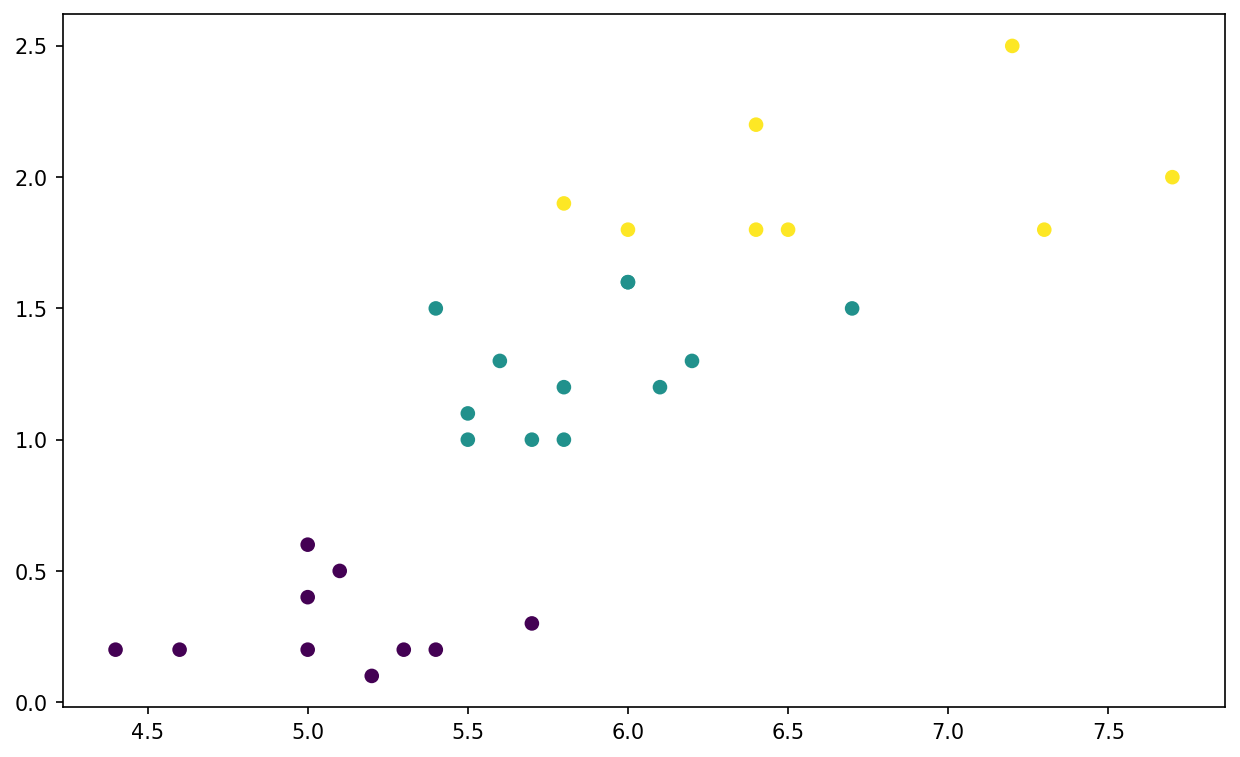

In [10]:
dataset = test_set

fig, ax = plt.subplots()
ax.scatter(dataset['SepalLengthCm'], dataset['PetalWidthCm'], c=pd.factorize(dataset['Species'])[0])


plt.show()

## Subdivide os conjuntos de treino e teste em conjuntos de características e conjunto de rótulos

In [11]:
X_train_set = train_set.drop(columns=['Species'])
y_train_set = train_set['Species'].copy()

X_test_set = test_set.drop(columns=['Species'])
y_test_set = test_set['Species'].copy()

## Define arquitetura da Árvore de Decisão e realiza o treinamento

In [12]:
dtc = DecisionTreeRegressor(criterion='squared_error', max_depth=None)#, random_state=42)
dtc.fit(X_train_set, y_train_set)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Cria uma representação gráfica do modelo gerado pelo método de árvore de decisão

### A representação é salva em dois arquivos:
### - iris_tree.dot
### - iris_tree.png

In [13]:
export_graphviz(
    dtc,
    out_file='iris_tree.dot',
    feature_names=X_train_set.columns,
    rounded=True,
    filled=True
)

! dot -Tpng iris_tree.dot -o iris_tree.png

## Exibe o arquivo iris_tree.png

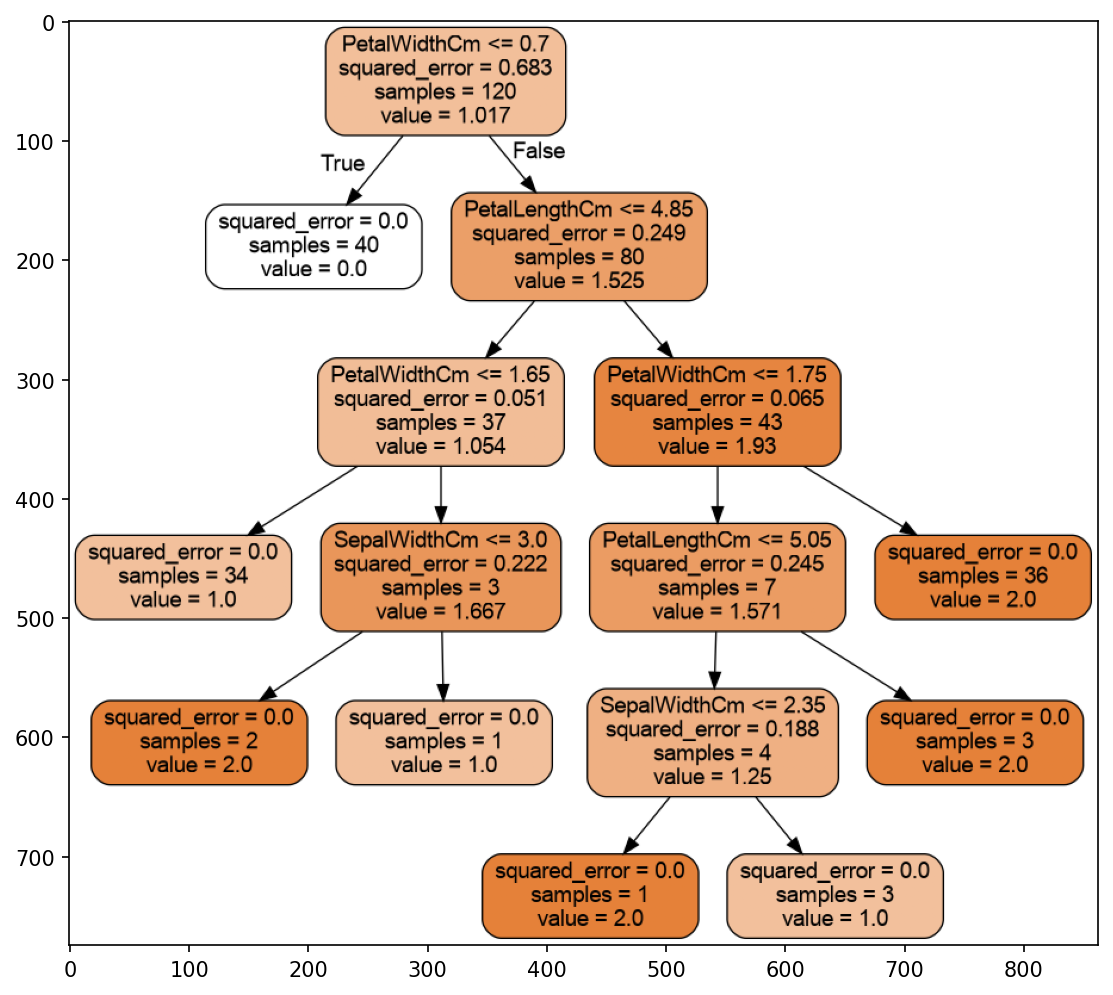

In [18]:
img = mpimg.imread('iris_tree.png')
plt.figure(figsize=(10, 8))
imgplot = plt.imshow(img)
plt.show()

## Gráfico alternativo

[Text(0.4, 0.9166666666666666, 'x[3] <= 0.7\nsquared_error = 0.683\nsamples = 120\nvalue = 1.017'),
 Text(0.3, 0.75, 'squared_error = 0.0\nsamples = 40\nvalue = 0.0'),
 Text(0.35, 0.8333333333333333, 'True  '),
 Text(0.5, 0.75, 'x[2] <= 4.85\nsquared_error = 0.249\nsamples = 80\nvalue = 1.525'),
 Text(0.45, 0.8333333333333333, '  False'),
 Text(0.2, 0.5833333333333334, 'x[3] <= 1.65\nsquared_error = 0.051\nsamples = 37\nvalue = 1.054'),
 Text(0.1, 0.4166666666666667, 'squared_error = 0.0\nsamples = 34\nvalue = 1.0'),
 Text(0.3, 0.4166666666666667, 'x[1] <= 3.0\nsquared_error = 0.222\nsamples = 3\nvalue = 1.667'),
 Text(0.2, 0.25, 'squared_error = 0.0\nsamples = 2\nvalue = 2.0'),
 Text(0.4, 0.25, 'squared_error = 0.0\nsamples = 1\nvalue = 1.0'),
 Text(0.8, 0.5833333333333334, 'x[3] <= 1.75\nsquared_error = 0.065\nsamples = 43\nvalue = 1.93'),
 Text(0.7, 0.4166666666666667, 'x[2] <= 5.05\nsquared_error = 0.245\nsamples = 7\nvalue = 1.571'),
 Text(0.6, 0.25, 'x[1] <= 2.35\nsquared_error =

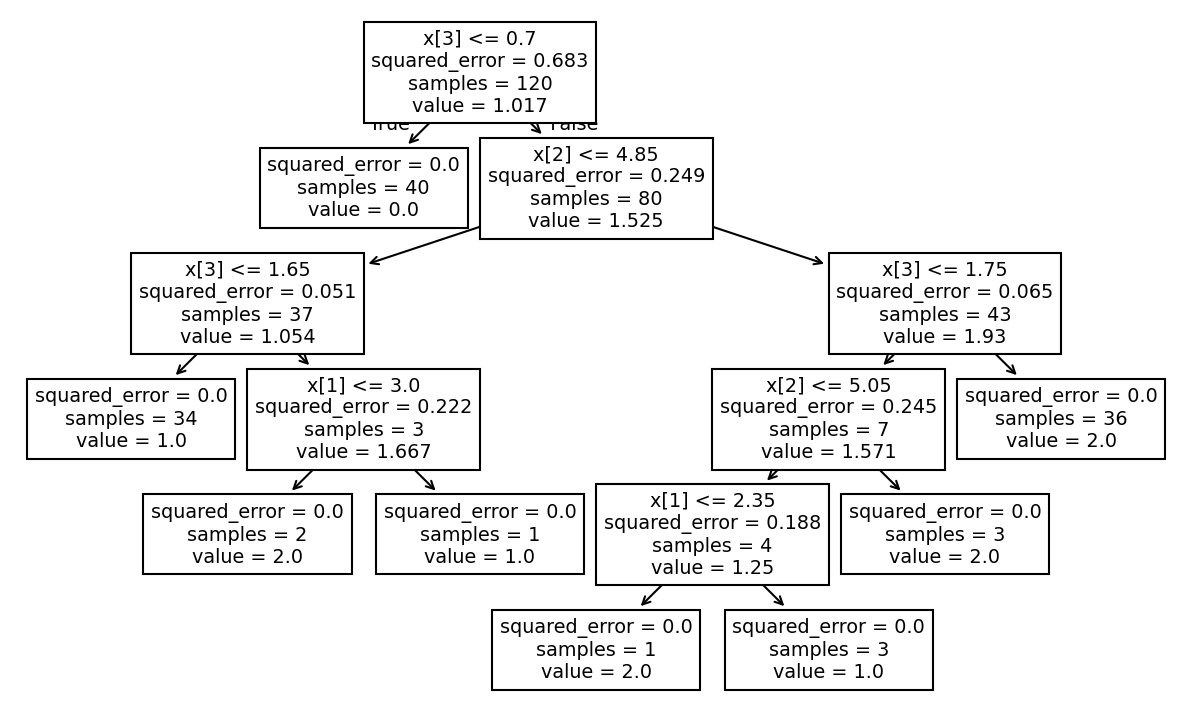

In [15]:
from sklearn import tree
tree.plot_tree(dtc)

## Realiza a predição do conjunto de teste e exibe o desempenho

### As métricas de desempenho utilizadas são: acurácia, revocação e precisão

In [16]:
predicts_dtc = dtc.predict(X_test_set)


print(f'MAE: {round(mean_absolute_error(y_test_set, predicts_dtc), 4)}')
print(f'MSE: {round(mean_squared_error(y_test_set, predicts_dtc), 4)}')
print(f'RMSE: {round(root_mean_squared_error(y_test_set, predicts_dtc), 4)}')

MAE: 0.0333
MSE: 0.0333
RMSE: 0.1826


## Pós-processamento da predição

Arredondando o valor predito para um número inteiro, assim é possível contar quantos erros existiram

In [17]:
predicts_dtc_round = [round(x, 0) for x in predicts_dtc]
print(f'Total de erros: {sum(predicts_dtc_round != y_test_set)}')

Total de erros: 1


# Exercício

## Altere a estrutura da árvore de regressão utilizada e, para cada configuração, replique pelo menos 3 vezes (gerando novos conjuntos de treino e teste) e indique a menor arquitetura encontrada. 

In [20]:
MAX_DEPTHS = (2, 3, 4, 5, None)

splitter = ShuffleSplit(n_splits=1, test_size=.20)
def split(splitter: ShuffleSplit, dataset: pd.DataFrame) -> tuple:
    strat_splits = []
    for train_index, test_index in splitter.split(dataset):
        train_set_n = dataset.iloc[train_index]
        test_set_n = dataset.iloc[test_index]
        strat_splits.append([train_set_n, test_set_n])


    train_set = strat_splits[0][0]
    test_set = strat_splits[0][1]

    return (train_set, test_set)

In [27]:
import numpy as np
resultados = np.zeros(len(MAX_DEPTHS))
for n_split in range(3000):
    train_set, test_set = split(splitter, dataset_iris)
    X_train_set = train_set.drop(columns=['Species'])
    y_train_set = train_set['Species'].copy()

    X_test_set = test_set.drop(columns=['Species'])
    y_test_set = test_set['Species'].copy()

    for i, depth in enumerate(MAX_DEPTHS):
        dtc = DecisionTreeRegressor(criterion='squared_error', max_depth=depth)
        dtc.fit(X_train_set, y_train_set)
        predicts_dtc = dtc.predict(X_test_set)
        
        resultados[i] += mean_squared_error(y_test_set, predicts_dtc)

resultados /= 3000
print("Menores erros quadraticos medios apos 3.000 iteracoes:")
pd.Series(resultados, name='Erro quadratico medio', index=MAX_DEPTHS).sort_values()

Menores erros quadraticos medios apos 3.000 iteracoes:


3.0    0.044469
5.0    0.053345
NaN    0.053478
4.0    0.053584
2.0    0.059698
Name: Erro quadratico medio, dtype: float64

Concluimos, portanto, que a menor e melhor altura eh 3.